## 1. Imports

In [1]:
import torch
import transformers
import datasets

## 2. First pipeline() — sentiment analysis

In [2]:
from transformers import pipeline

sentiment = pipeline("sentiment-analysis")

texts = [
    "I absolutely loved this movie!",
    "The movie was boring and disappointing.",
    "The acting was good, but the story was weak."
]

results = sentiment(texts)

for text, result in zip(texts, results):
    print(text)
    print(result)
    print()

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

I absolutely loved this movie!
{'label': 'POSITIVE', 'score': 0.9998785257339478}

The movie was boring and disappointing.
{'label': 'NEGATIVE', 'score': 0.9997933506965637}

The acting was good, but the story was weak.
{'label': 'NEGATIVE', 'score': 0.9979214072227478}



## 3. NER pipeline

In [3]:
ner = pipeline(
    "ner",
    model="dslim/distilbert-NER",
    aggregation_strategy="first"
)

text = "My name is Farhad and I studied Computer Science at UMT in Lahore."

entities = ner(text)

for entity in entities:
    print(entity)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

{'entity_group': 'PER', 'score': np.float32(0.9976509), 'word': 'Farhad', 'start': 11, 'end': 17}
{'entity_group': 'MISC', 'score': np.float32(0.762426), 'word': 'Computer Science', 'start': 32, 'end': 48}
{'entity_group': 'ORG', 'score': np.float32(0.99521625), 'word': 'UMT', 'start': 52, 'end': 55}
{'entity_group': 'LOC', 'score': np.float32(0.98431104), 'word': 'Lahore', 'start': 59, 'end': 65}


## 4. Let's go underneath pipeline()

In [4]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [5]:
text = "I absolutely loved this movie!"

tokens = tokenizer.tokenize(text)

print(tokens)

['i', 'absolutely', 'loved', 'this', 'movie', '!']


In [6]:
encoded = tokenizer(
    text,
    return_tensors="pt"
)

print(encoded)

{'input_ids': tensor([[ 101, 1045, 7078, 3866, 2023, 3185,  999,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}


In [7]:
print("Input IDs:")
print(encoded["input_ids"])

print("\nAttention Mask:")
print(encoded["attention_mask"])

Input IDs:
tensor([[ 101, 1045, 7078, 3866, 2023, 3185,  999,  102]])

Attention Mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 1]])


In [8]:
from transformers import AutoModel

model = AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
outputs = model(**encoded)

print(outputs.last_hidden_state.shape)

torch.Size([1, 8, 768])


In [10]:
hidden_states = outputs.last_hidden_state

print("Shape:", hidden_states.shape)
print("\nRepresentation of [CLS]:")
print(hidden_states[0, 0])

print("\nRepresentation of 'loved':")
print(hidden_states[0, 3])

Shape: torch.Size([1, 8, 768])

Representation of [CLS]:
tensor([ 7.2176e-01,  6.4155e-02,  5.6655e-03,  3.4716e-02,  9.0660e-01,
        -4.3272e-01, -3.5091e-01,  7.3201e-01, -6.7278e-01,  3.1166e-01,
        -3.4004e-01,  6.2153e-01,  6.1843e-01,  1.9007e-01,  2.4553e-01,
        -4.1136e-02,  8.8809e-01,  8.7868e-01, -1.5816e-01, -6.1053e-01,
        -1.7642e-01, -5.5851e-01, -3.2572e-01,  4.8336e-01, -3.0394e-01,
        -2.1225e-01, -8.4556e-01,  3.4532e-02, -3.3983e-01, -1.4395e-01,
         5.6780e-01, -4.6324e-01, -2.4491e-01, -3.1245e-02, -1.5493e-01,
         4.9237e-01, -5.6483e-02, -3.6264e-01, -1.3683e+00, -1.1087e+00,
        -2.7711e-01,  9.1531e-01,  1.4718e+00, -7.8270e-01, -9.6101e-01,
        -1.2225e+00, -2.6707e-02,  7.4491e-01, -1.8528e-01, -1.7995e-02,
        -5.3954e-01,  3.0508e-01, -8.9580e-01, -2.5824e-01,  5.5240e-01,
         8.5278e-01, -1.0149e+00,  4.6270e-01, -7.3891e-01, -1.7240e+00,
        -3.4453e-01, -2.1808e-01,  3.4031e-01, -4.3597e-01,  1.4228

In [11]:
print("CLS:", hidden_states[0, 0, :10])
print("loved:", hidden_states[0, 3, :10])

CLS: tensor([ 0.7218,  0.0642,  0.0057,  0.0347,  0.9066, -0.4327, -0.3509,  0.7320,
        -0.6728,  0.3117], grad_fn=<SliceBackward0>)
loved: tensor([ 0.9989,  0.1771,  0.0786,  0.0287,  0.9648, -0.4569, -0.4394,  0.8820,
        -0.6220,  0.2718], grad_fn=<SliceBackward0>)


In [12]:
sentences = [
    "I went to the bank to deposit money.",
    "I sat on the bank of the river."
]

In [13]:
encoded = tokenizer(
    sentences,
    padding=True,
    return_tensors="pt"
)

encoded = {
    k: v.to("cuda")
    for k, v in encoded.items()
}

In [14]:
model = model.to("cuda")

In [15]:
with torch.no_grad():
    outputs = model(**encoded)

hidden_states = outputs.last_hidden_state

In [16]:
for sentence in sentences:
    print(tokenizer.tokenize(sentence))

['i', 'went', 'to', 'the', 'bank', 'to', 'deposit', 'money', '.']
['i', 'sat', 'on', 'the', 'bank', 'of', 'the', 'river', '.']


In [17]:
bank_1 = hidden_states[0, 4]
bank_2 = hidden_states[1, 4]

print("Bank 1:", bank_1[:10])
print("Bank 2:", bank_2[:10])

Bank 1: tensor([-0.3439,  0.4053, -0.4098, -0.0419, -0.2130,  0.1384,  0.3182,  1.2818,
         0.0280,  0.0881], device='cuda:0')
Bank 2: tensor([-0.1446, -0.0862,  0.0256, -0.0338,  0.2784,  0.4609, -0.2046,  0.7986,
        -0.4457, -0.5193], device='cuda:0')


In [18]:
similarity = torch.nn.functional.cosine_similarity(
    bank_1.unsqueeze(0),
    bank_2.unsqueeze(0)
)

print("Cosine similarity:", similarity.item())

Cosine similarity: 0.319399893283844


## 5. Self-Attention

In [19]:
from transformers import AutoModel

model = AutoModel.from_pretrained(
    model_name,
    attn_implementation="eager"
)

model = model.to("cuda")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
text = "The bank approved my loan."

encoded = tokenizer(
    text,
    return_tensors="pt"
)

encoded = {
    k: v.to("cuda")
    for k, v in encoded.items()
}

In [21]:
with torch.no_grad():
    outputs = model(
        **encoded,
        output_attentions=True
    )

In [22]:
print(len(outputs.attentions))

6


In [23]:
print(outputs.attentions[0].shape)

torch.Size([1, 12, 8, 8])


In [24]:
tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
print(tokens)

['[CLS]', 'the', 'bank', 'approved', 'my', 'loan', '.', '[SEP]']


In [25]:
attention = outputs.attentions[0][0, 0]

print(attention.shape)

torch.Size([8, 8])


In [26]:
print(attention.sum(dim=-1))

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       device='cuda:0')


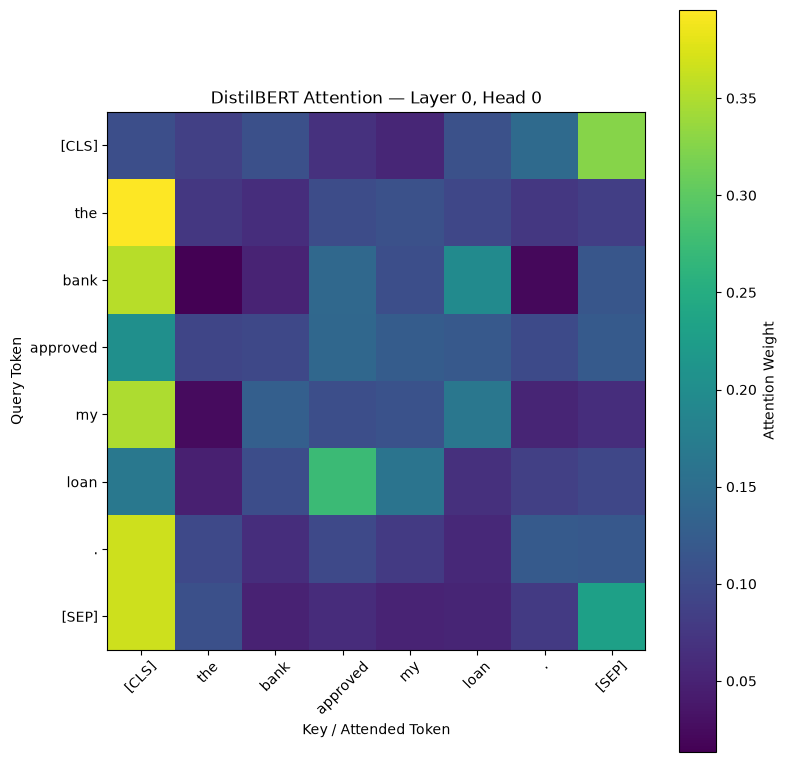

In [27]:
import matplotlib.pyplot as plt

tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

plt.figure(figsize=(8, 8))
plt.imshow(attention.cpu().numpy())

plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.yticks(range(len(tokens)), tokens)

plt.xlabel("Key / Attended Token")
plt.ylabel("Query Token")
plt.title("DistilBERT Attention — Layer 0, Head 0")

plt.colorbar(label="Attention Weight")
plt.tight_layout()
plt.show()

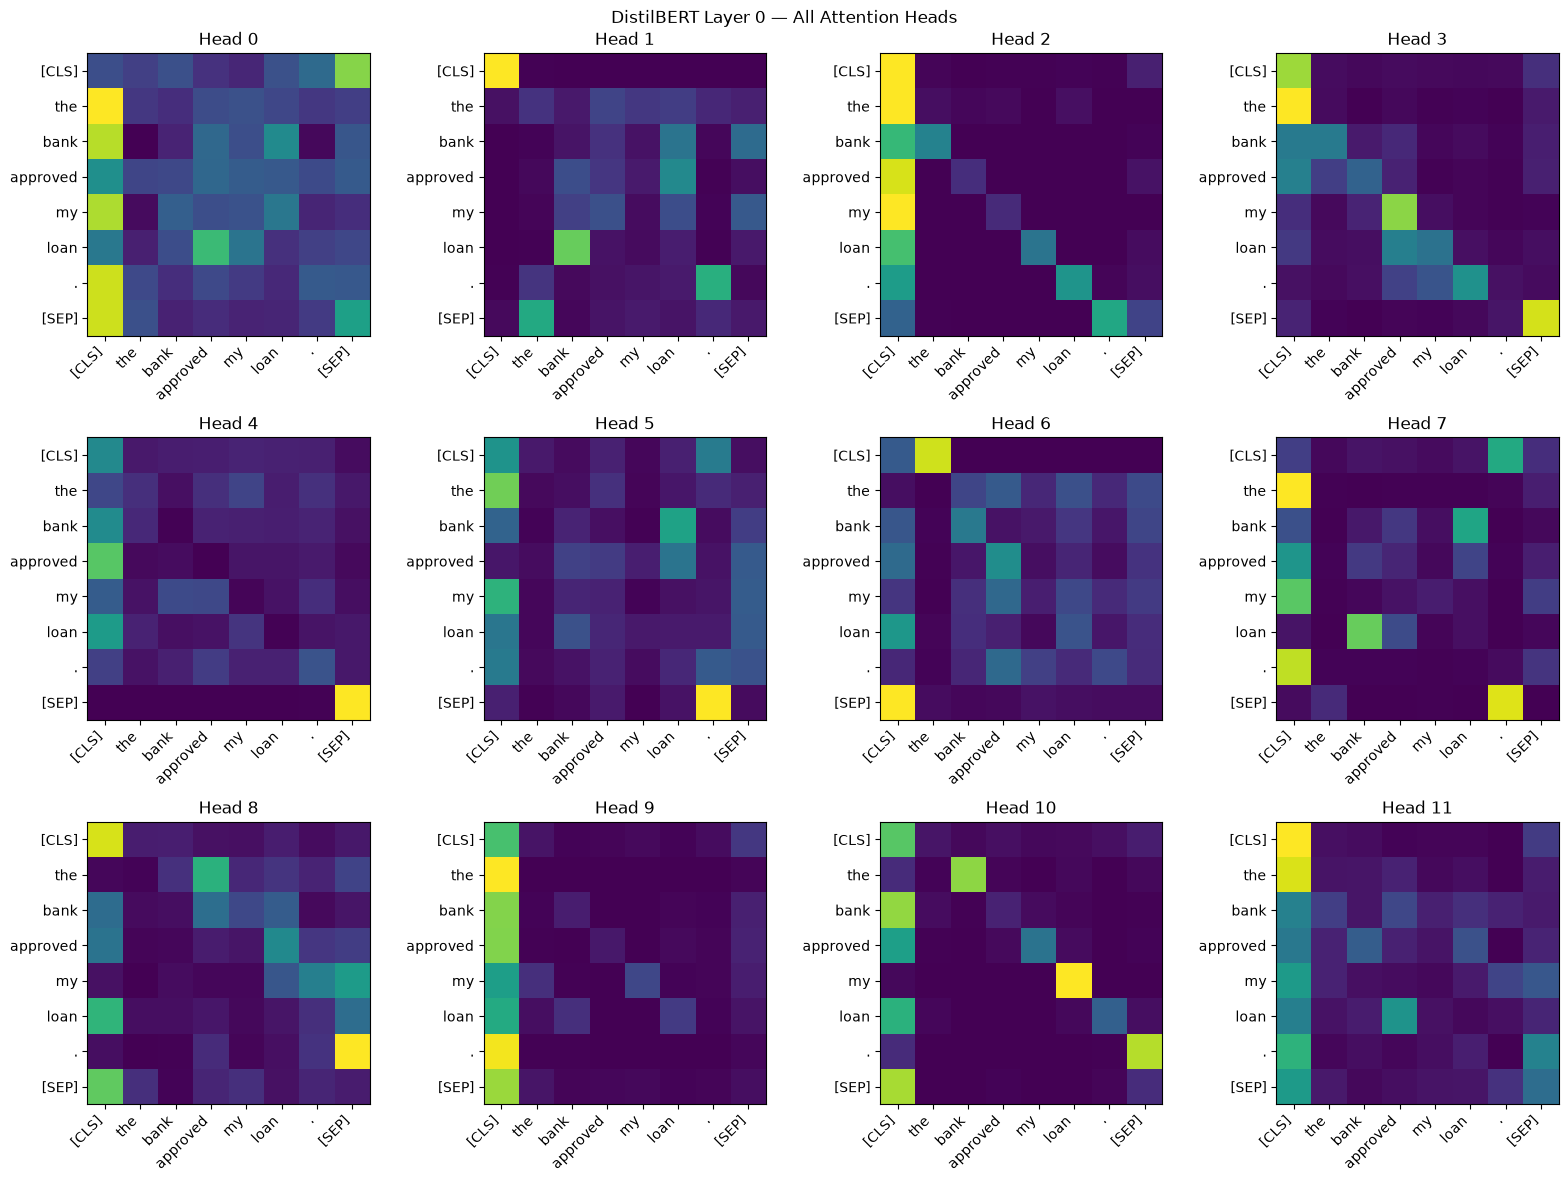

In [28]:
import matplotlib.pyplot as plt

layer = 0
attentions = outputs.attentions[layer][0].detach().cpu()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for head, ax in enumerate(axes.flat):
    ax.imshow(attentions[head].numpy())

    ax.set_title(f"Head {head}")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))

    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_yticklabels(tokens)

plt.suptitle("DistilBERT Layer 0 — All Attention Heads")
plt.tight_layout()
plt.show()

In [29]:
print(model)

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [30]:
print("Hidden size:", model.config.dim)
print("Number of layers:", model.config.n_layers)
print("Attention heads:", model.config.n_heads)
print("FFN dimension:", model.config.hidden_dim)

Hidden size: 768
Number of layers: 6
Attention heads: 12
FFN dimension: 3072


# Fine-Tuning vs Feature Extraction

## Step 1: Load the dataset

In [31]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [32]:
train_dataset = dataset["train"]
test_dataset = dataset["test"]

## Step 2: Tokenize the dataset

In [33]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

In [34]:
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

In [35]:
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

## Load the sequence-classification model

In [36]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1}
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Check the model

In [37]:
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [38]:
print("Hidden size:", model.config.dim)
print("Layers:", model.config.n_layers)
print("Attention heads:", model.config.n_heads)
print("Labels:", model.config.num_labels)

Hidden size: 768
Layers: 6
Attention heads: 12
Labels: 2


## Move it to GPU

In [39]:
model = model.to("cuda")

In [40]:
print(next(model.parameters()).device)

cuda:0


In [41]:
print(tokenized_train.column_names)

['labels', 'input_ids', 'token_type_ids', 'attention_mask']


## Training configuration

In [42]:
# Use a smaller subset for faster experimentation
small_train = tokenized_train.shuffle(seed=42).select(range(5000))

print("Training examples:", len(small_train))
print("Validation examples:", len(tokenized_test))

Training examples: 5000
Validation examples: 25000


In [43]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert-imdb",

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,

    num_train_epochs=1,

    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    report_to="none"
)

## Evaluation Metric

In [44]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## Create the Trainer

In [45]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [46]:
print(torch.cuda.memory_allocated() / 1024**2, "MB allocated")
print(torch.cuda.memory_reserved() / 1024**2, "MB reserved")

771.06689453125 MB allocated
830.0 MB reserved


In [47]:
print("Model device:", next(model.parameters()).device)

Model device: cuda:0


## Train the model

In [48]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.480098,0.446928,0.848320,0.833589,0.870400,0.851597


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1250, training_loss=0.4864873336791992, metrics={'train_runtime': 1462.8092, 'train_samples_per_second': 3.418, 'train_steps_per_second': 0.855, 'total_flos': 165584248320000.0, 'train_loss': 0.4864873336791992, 'epoch': 1.0})

## Evaluate on Test Set

In [49]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.480098,0.446928,1,0.848320,0.833589,0.870400,0.851597


{'eval_loss': 0.44692811369895935, 'eval_accuracy': 0.84832, 'eval_precision': 0.8335887220349372, 'eval_recall': 0.8704, 'eval_f1': 0.8515967438948028}


## Test the fine-tuned model on new sentences

In [51]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="./distilbert-imdb/checkpoint-1250",
    tokenizer=tokenizer
)

texts = [
    "This movie was absolutely fantastic.",
    "The movie was terrible and boring.",
    "I really enjoyed the story and acting."
]

for text in texts:
    print(text)
    print(classifier(text))
    print()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

This movie was absolutely fantastic.
[{'label': 'POSITIVE', 'score': 0.9888625741004944}]

The movie was terrible and boring.
[{'label': 'NEGATIVE', 'score': 0.9910900592803955}]

I really enjoyed the story and acting.
[{'label': 'POSITIVE', 'score': 0.9878782629966736}]



## Feature Extraction

## Step 1: Create a frozen DistilBERT

In [53]:
from transformers import AutoModel

feature_model = AutoModel.from_pretrained("distilbert-base-uncased")
feature_model = feature_model.to('cuda')

for param in feature_model.parameters():
    param.requires_grad = False

feature_model.eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

Verify that it's actually frozen:

In [54]:
print(
    "Trainable parameters:",
    sum(p.numel() for p in feature_model.parameters() if p.requires_grad)
)

Trainable parameters: 0


## Step 2: Create a DataLoader

In [73]:
small_test = tokenized_test.shuffle(seed=42).select(range(5000))

print("Training examples:", len(small_train))
print("Test examples:", len(small_test))

Training examples: 5000
Test examples: 5000


In [74]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    small_train,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    small_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Batch size:", train_loader.batch_size)

Batch size: 32


In [77]:
small_train.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

small_test.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [78]:
batch = next(iter(train_loader))

print(batch.keys())
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

dict_keys(['labels', 'input_ids', 'attention_mask'])
torch.Size([32, 128])
torch.Size([32, 128])
torch.Size([32])


## Step 3: Extract frozen DistilBERT features

In [79]:
def extract_features(model, dataloader, device):
    features = []
    labels = []

    model.eval()

    with torch.inference_mode():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            cls_features = outputs.last_hidden_state[:, 0, :]

            features.append(cls_features.cpu())
            labels.append(batch["labels"])

    features = torch.cat(features)
    labels = torch.cat(labels)

    return features, labels

In [80]:
import time

feature_model.eval()

start = time.time()

with torch.inference_mode():
    for i, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to("cuda", non_blocking=True)
        attention_mask = batch["attention_mask"].to("cuda", non_blocking=True)

        outputs = feature_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        if i == 9:
            break

elapsed = time.time() - start

print(f"10 batches took {elapsed:.2f} seconds")
print(f"Estimated training extraction: {elapsed / 10 * len(train_loader) / 60:.1f} minutes")

10 batches took 82.58 seconds
Estimated training extraction: 21.6 minutes


In [81]:
train_features, train_labels = extract_features(
    feature_model,
    train_loader,
    'cuda'
)

test_features, test_labels = extract_features(
    feature_model,
    test_loader,
    'cuda'
)

In [82]:
print("Train features:", train_features.shape)
print("Train labels:", train_labels.shape)

print("Test features:", test_features.shape)
print("Test labels:", test_labels.shape)

Train features: torch.Size([5000, 768])
Train labels: torch.Size([5000])
Test features: torch.Size([5000, 768])
Test labels: torch.Size([5000])


In [83]:
print("Feature dtype:", train_features.dtype)
print("Label dtype:", train_labels.dtype)

print("First feature vector:", train_features[0][:10])
print("First label:", train_labels[0].item())

Feature dtype: torch.float32
Label dtype: torch.int64
First feature vector: tensor([-0.1315, -0.1870, -0.0168,  0.0154, -0.0851, -0.2563,  0.1664,  0.2952,
        -0.0329, -0.3142])
First label: 1


## Step 4: Train a classifier on the frozen features

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train = train_features.numpy()
y_train = train_labels.numpy()

X_test = test_features.numpy()
y_test = test_labels.numpy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5000, 768)
X_test: (5000, 768)


In [85]:
clf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [86]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8104
Accuracy: 81.04%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      2494
           1       0.81      0.81      0.81      2506

    accuracy                           0.81      5000
   macro avg       0.81      0.81      0.81      5000
weighted avg       0.81      0.81      0.81      5000



## Step 5: PCA on frozen DistilBERT features

In [87]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_test_pca = pca.fit_transform(X_test)

print("Original shape:", X_test.shape)
print("PCA shape:", X_test_pca.shape)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

Original shape: (5000, 768)
PCA shape: (5000, 2)
Explained variance ratio: [0.09748238 0.07089332]
Total explained variance: 0.1684


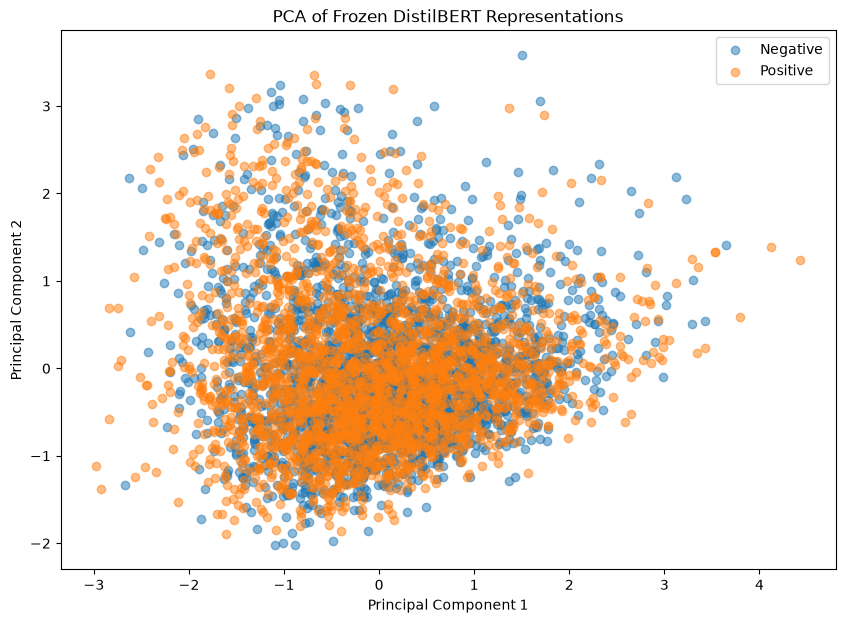

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    X_test_pca[y_test == 0, 0],
    X_test_pca[y_test == 0, 1],
    label="Negative",
    alpha=0.5
)

plt.scatter(
    X_test_pca[y_test == 1, 0],
    X_test_pca[y_test == 1, 1],
    label="Positive",
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Frozen DistilBERT Representations")
plt.legend()
plt.show()

In [89]:
pca_full = PCA(n_components=0.95, random_state=42)
pca_full.fit(X_train)

print("Original dimensions:", X_train.shape[1])
print("Components for 95% variance:", pca_full.n_components_)

Original dimensions: 768
Components for 95% variance: 240


## Step 6: Nonlinear classifier on the frozen features

In [90]:
import torch.nn as nn

class FeatureClassifier(nn.Module):
    def __init__(self, input_dim=768):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.classifier(x)

In [91]:
feature_classifier = FeatureClassifier().to("cuda")

print(feature_classifier)

FeatureClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [95]:
from torch.utils.data import TensorDataset, DataLoader

X_train = train_features
y_train = train_labels

X_test = test_features
y_test = test_labels

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: torch.Size([5000, 768])
Test: torch.Size([5000, 768])


In [96]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FeatureClassifier(input_dim=768).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(model)

FeatureClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [98]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/20 | Loss: 0.3975 | Accuracy: 0.8214
Epoch 2/20 | Loss: 0.3936 | Accuracy: 0.8220
Epoch 3/20 | Loss: 0.3870 | Accuracy: 0.8200
Epoch 4/20 | Loss: 0.3917 | Accuracy: 0.8240
Epoch 5/20 | Loss: 0.3930 | Accuracy: 0.8222
Epoch 6/20 | Loss: 0.3839 | Accuracy: 0.8326
Epoch 7/20 | Loss: 0.3793 | Accuracy: 0.8304
Epoch 8/20 | Loss: 0.3800 | Accuracy: 0.8268
Epoch 9/20 | Loss: 0.3772 | Accuracy: 0.8256
Epoch 10/20 | Loss: 0.3779 | Accuracy: 0.8298
Epoch 11/20 | Loss: 0.3695 | Accuracy: 0.8348
Epoch 12/20 | Loss: 0.3679 | Accuracy: 0.8372
Epoch 13/20 | Loss: 0.3626 | Accuracy: 0.8384
Epoch 14/20 | Loss: 0.3612 | Accuracy: 0.8410
Epoch 15/20 | Loss: 0.3497 | Accuracy: 0.8406
Epoch 16/20 | Loss: 0.3448 | Accuracy: 0.8428
Epoch 17/20 | Loss: 0.3404 | Accuracy: 0.8478
Epoch 18/20 | Loss: 0.3467 | Accuracy: 0.8424
Epoch 19/20 | Loss: 0.3407 | Accuracy: 0.8478
Epoch 20/20 | Loss: 0.3324 | Accuracy: 0.8536


In [99]:
model.eval()

test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        predictions = outputs.argmax(dim=1)

        test_correct += (predictions == y_batch).sum().item()
        test_total += y_batch.size(0)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

test_accuracy = test_correct / test_total

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 0.8068
Test Accuracy: 80.68%


In [100]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds
    )
)

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      2494
           1       0.81      0.81      0.81      2506

    accuracy                           0.81      5000
   macro avg       0.81      0.81      0.81      5000
weighted avg       0.81      0.81      0.81      5000

